<a href="https://colab.research.google.com/github/patel473/Book-Recommendation-System/blob/main/Project_Intelligent_Network_Intrusion_Detection_System_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project: Intelligent Network Intrusion Detection System Using Machine Learning**

**Section 1: Environment Setup and Library Installation**

In [ ]:
# Section 1: Environment Setup and Library Installation

# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost
!pip install tensorflow keras
!pip install joblib

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, auc,
                            precision_recall_curve)

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Handling imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# System and file handling
import joblib
import os
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"🔹 TensorFlow version: {tf.__version__}")
print(f"🔹 Scikit-learn version: {pd.__version__}")

✅ All libraries imported successfully!
🔹 TensorFlow version: 2.19.0
🔹 Scikit-learn version: 2.2.2


**Section 2: Load and Explore Dataset (NSL-KDD Dataset)**

In [ ]:
# Section 2: Load and Explore Dataset

# Download NSL-KDD dataset
!wget http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSV/MachineLearningCSV.zip
!unzip -q MachineLearningCSV.zip -d datasets/

# Alternatively, let's use a preprocessed version of NSL-KDD for faster implementation
!wget https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
!wget https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt

# Define column names for NSL-KDD dataset
col_names = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
             "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
             "root_shell","su_attempted","num_root","num_file_creations","num_shells",
             "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
             "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
             "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
             "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
             "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
             "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
             "label","difficulty"]

# Load training and test data
train_df = pd.read_csv('KDDTrain+.txt', names=col_names)
test_df = pd.read_csv('KDDTest+.txt', names=col_names)

print("✅ Dataset loaded successfully!")
print(f"🔹 Training set shape: {train_df.shape}")
print(f"🔹 Test set shape: {test_df.shape}")

# Display first few rows
print("\n📊 First 5 rows of training data:")
train_df.head()

--2026-02-23 22:14:32--  http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSV/MachineLearningCSV.zip
Connecting to 205.174.165.80:80... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-02-23 22:14:32 ERROR 403: Forbidden.

unzip:  cannot find or open MachineLearningCSV.zip, MachineLearningCSV.zip.zip or MachineLearningCSV.zip.ZIP.
--2026-02-23 22:14:32--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt’

KDDTrain+.txt       100%[===================>]  18.22M  --.-KB/s    in 0.1s    

2026-02-23 22:14:33 (153 MB/s) - ‘KDDTrain+.txt’ saved [19109424/19109424]

--2026-02-23 22:14:33--  https://raw

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


**Section 3: Exploratory Data Analysis (EDA)**

📊 Dataset Information:
--------------------------------------------------
Total samples in training: 125973
Total samples in testing: 22544
Total features: 43

🔍 Missing values in training set:
0
✅ No missing values found!

📈 Statistical Summary of Numerical Features:
--------------------------------------------------

📋 Data Types:
--------------------------------------------------
int64      24
float64    15
object      4
Name: count, dtype: int64

Feature types:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell             

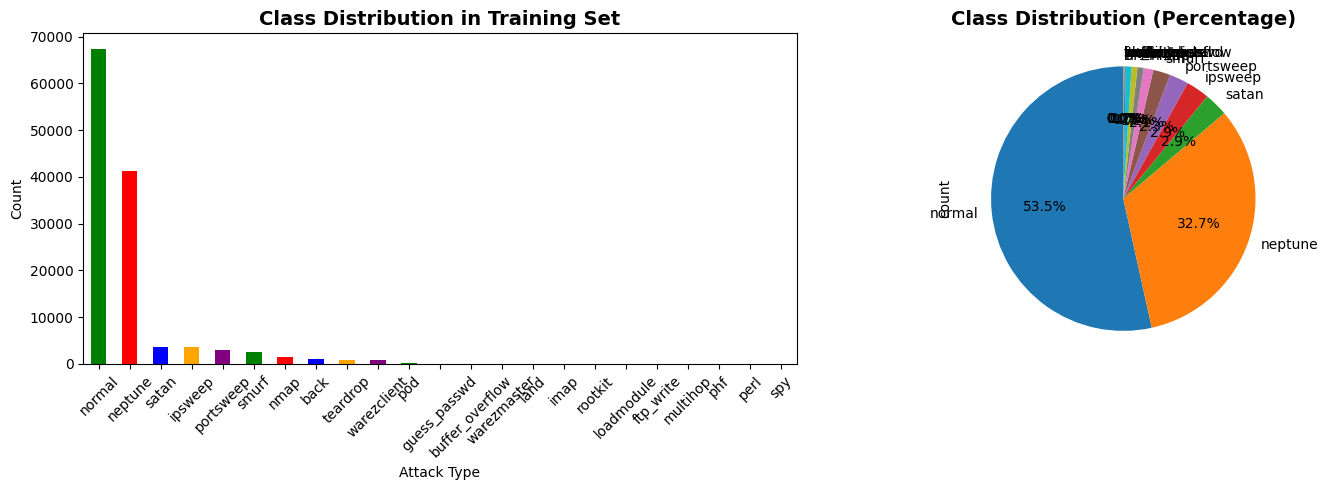

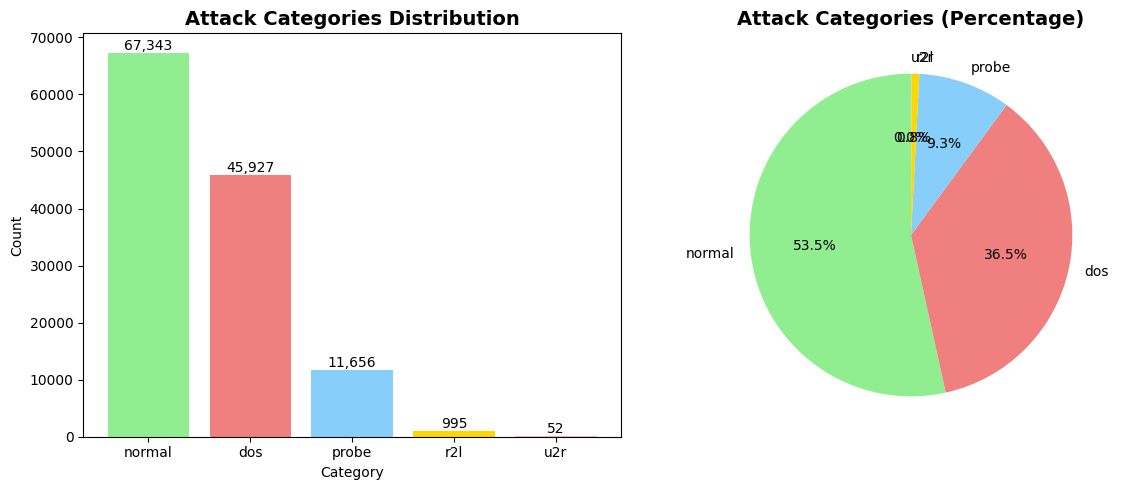


📊 Attack Category Distribution:
attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64


In [ ]:
# Section 3: Exploratory Data Analysis

# Basic information about the dataset
print("📊 Dataset Information:")
print("-" * 50)
print(f"Total samples in training: {len(train_df)}")
print(f"Total samples in testing: {len(test_df)}")
print(f"Total features: {len(train_df.columns)}")

# Check for missing values
print("\n🔍 Missing values in training set:")
print(train_df.isnull().sum().sum())
print("✅ No missing values found!")

# Statistical summary
print("\n📈 Statistical Summary of Numerical Features:")
print("-" * 50)
train_df.describe()

# Data types
print("\n📋 Data Types:")
print("-" * 50)
print(train_df.dtypes.value_counts())
print("\nFeature types:")
print(train_df.dtypes)

# Class distribution analysis
print("\n🎯 Class Distribution in Training Set:")
print("-" * 50)
label_counts = train_df['label'].value_counts()
print(label_counts)

# Visualize class distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color=['green', 'red', 'blue', 'orange', 'purple'])
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
label_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Analyze attack categories
def categorize_attack(label):
    if label == 'normal':
        return 'normal'
    elif label in ['ipsweep', 'nmap', 'portsweep', 'satan']:
        return 'probe'
    elif label in ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop']:
        return 'dos'
    elif label in ['buffer_overflow', 'loadmodule', 'perl', 'rootkit']:
        return 'u2r'
    elif label in ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster']:
        return 'r2l'
    else:
        return 'unknown'

# Create attack categories
train_df['attack_category'] = train_df['label'].apply(categorize_attack)
test_df['attack_category'] = test_df['label'].apply(categorize_attack)

# Visualize attack categories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
category_counts = train_df['attack_category'].value_counts()
colors = ['lightgreen', 'lightcoral', 'lightskyblue', 'gold', 'lightpink']
bars = plt.bar(category_counts.index, category_counts.values, color=colors)
plt.title('Attack Categories Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Attack Categories (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Attack Category Distribution:")
print(category_counts)

**Section 4: Data Preprocessing**

In [ ]:
# ================================
# Section 4: Data Preprocessing
# ================================

print("🚀 Starting Data Preprocessing...\n")

# ------------------------------
# 1️⃣ Separate features and labels
# ------------------------------
X_train = train_df.drop(['label', 'difficulty', 'attack_category'], axis=1)
X_test = test_df.drop(['label', 'difficulty', 'attack_category'], axis=1)

# 🔹 Use attack_category as target (recommended)
y_train = train_df['attack_category']
y_test = test_df['attack_category']

print("🔹 Before encoding:")
print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# ------------------------------
# 2️⃣ Identify categorical & numerical columns
# ------------------------------
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"\n📊 Categorical columns: {categorical_cols}")
print(f"📊 Numerical columns: {len(numerical_cols)} columns")

# ------------------------------
# 3️⃣ Encode categorical features
# ------------------------------
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()

    combined = pd.concat([X_train[col], X_test[col]], axis=0)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

    le_dict[col] = le

    print(f"✅ Encoded {col}: {len(le.classes_)} unique values")

# ------------------------------
# 4️⃣ Encode target variable
# ------------------------------
target_le = LabelEncoder()

combined_target = pd.concat([y_train, y_test], axis=0)
target_le.fit(combined_target)

y_train_encoded = target_le.transform(y_train)
y_test_encoded = target_le.transform(y_test)

print(f"\n🎯 Target classes: {target_le.classes_}")
print(f"Class mapping: {dict(zip(target_le.classes_, range(len(target_le.classes_))))}")

# ------------------------------
# 5️⃣ Feature scaling
# ------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n✅ Feature scaling completed!")

# ------------------------------
# 6️⃣ Final dataset info
# ------------------------------
print("\n📦 Final Processed Shapes:")
print(f"🔹 X_train_scaled: {X_train_scaled.shape}")
print(f"🔹 X_test_scaled: {X_test_scaled.shape}")
print(f"🔹 y_train_encoded: {y_train_encoded.shape}")
print(f"🔹 y_test_encoded: {y_test_encoded.shape}")

# ------------------------------
# 7️⃣ Class distribution
# ------------------------------
print("\n📊 Class distribution (training):")

unique, counts = np.unique(y_train_encoded, return_counts=True)

for cls, count in zip(target_le.classes_, counts):
    print(f"   {cls}: {count} samples ({count/len(y_train_encoded)*100:.2f}%)")

print("\n🎉 Preprocessing completed successfully!")

🚀 Starting Data Preprocessing...

🔹 Before encoding:
Training features shape: (125973, 41)
Training labels shape: (125973,)
Test features shape: (22544, 41)
Test labels shape: (22544,)

📊 Categorical columns: ['protocol_type', 'service', 'flag']
📊 Numerical columns: 38 columns
✅ Encoded protocol_type: 3 unique values
✅ Encoded service: 70 unique values
✅ Encoded flag: 11 unique values

🎯 Target classes: ['dos' 'normal' 'probe' 'r2l' 'u2r' 'unknown']
Class mapping: {'dos': 0, 'normal': 1, 'probe': 2, 'r2l': 3, 'u2r': 4, 'unknown': 5}

✅ Feature scaling completed!

📦 Final Processed Shapes:
🔹 X_train_scaled: (125973, 41)
🔹 X_test_scaled: (22544, 41)
🔹 y_train_encoded: (125973,)
🔹 y_test_encoded: (22544,)

📊 Class distribution (training):
   dos: 45927 samples (36.46%)
   normal: 67343 samples (53.46%)
   probe: 11656 samples (9.25%)
   r2l: 995 samples (0.79%)
   u2r: 52 samples (0.04%)

🎉 Preprocessing completed successfully!


**Section 5: Handle Imbalanced Data**

🔄 Handling Imbalanced Data with SMOTE...

📊 Original class distribution:
   dos: 45927 samples (36.46%)
   normal: 67343 samples (53.46%)
   probe: 11656 samples (9.25%)
   r2l: 995 samples (0.79%)
   u2r: 52 samples (0.04%)

✅ SMOTE applied successfully!
🔹 Original training set shape: (125973, 41)
🔹 Balanced training set shape: (336715, 41)

📊 Balanced class distribution:
   dos: 67343 samples (20.00%)
   normal: 67343 samples (20.00%)
   probe: 67343 samples (20.00%)
   r2l: 67343 samples (20.00%)
   u2r: 67343 samples (20.00%)


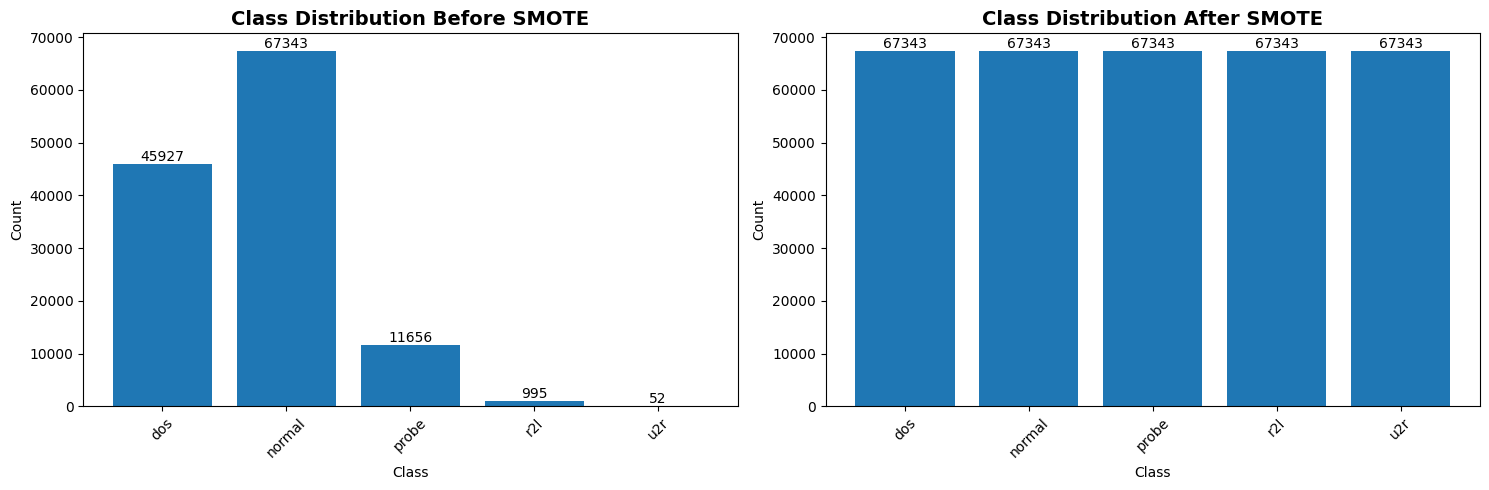


🔄 Trying SMOTE-Tomek for comparison...
SMOTE-Tomek result shape: (336663, 41)

🎉 Imbalance handling completed!


In [ ]:
# ================================
# Section 5: Handle Imbalanced Data
# ================================

print("🔄 Handling Imbalanced Data with SMOTE...")

# ------------------------------
# 1️⃣ Class distribution BEFORE SMOTE
# ------------------------------
unique, counts = np.unique(y_train_encoded, return_counts=True)

class_labels = target_le.inverse_transform(unique)

print("\n📊 Original class distribution:")
for cls, count in zip(class_labels, counts):
    print(f"   {cls}: {count} samples ({count/len(y_train_encoded)*100:.2f}%)")

# ------------------------------
# 2️⃣ Apply SMOTE
# ------------------------------
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_encoded)

print("\n✅ SMOTE applied successfully!")
print(f"🔹 Original training set shape: {X_train_scaled.shape}")
print(f"🔹 Balanced training set shape: {X_train_balanced.shape}")

# ------------------------------
# 3️⃣ Class distribution AFTER SMOTE
# ------------------------------
unique_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)
class_labels_bal = target_le.inverse_transform(unique_bal)

print("\n📊 Balanced class distribution:")
for cls, count in zip(class_labels_bal, counts_bal):
    print(f"   {cls}: {count} samples ({count/len(y_train_balanced)*100:.2f}%)")

# ------------------------------
# 4️⃣ Visualization
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before SMOTE
axes[0].bar(class_labels, counts)
axes[0].set_title('Class Distribution Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

for i, count in enumerate(counts):
    axes[0].text(i, count, str(count), ha='center', va='bottom')

# After SMOTE
axes[1].bar(class_labels_bal, counts_bal)
axes[1].set_title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

for i, count in enumerate(counts_bal):
    axes[1].text(i, count, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ------------------------------
# 5️⃣ SMOTE-Tomek (optional)
# ------------------------------
print("\n🔄 Trying SMOTE-Tomek for comparison...")
smote_tomek = SMOTETomek(random_state=42)
X_train_bal_tomek, y_train_bal_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_encoded)

print(f"SMOTE-Tomek result shape: {X_train_bal_tomek.shape}")

print("\n🎉 Imbalance handling completed!")

**Section 6: Feature Selection and Importance Analysis**

🌲 Analyzing Feature Importance with Random Forest...

📊 Top 20 Most Important Features:
--------------------------------------------------
                    feature  importance
                  src_bytes    0.108077
         dst_host_srv_count    0.094304
                  dst_bytes    0.078798
                  logged_in    0.076695
                    service    0.062438
                  srv_count    0.040891
       dst_host_serror_rate    0.039339
                      count    0.038729
dst_host_same_src_port_rate    0.037190
            srv_serror_rate    0.033662
                serror_rate    0.031034
     dst_host_diff_srv_rate    0.030418
                   duration    0.028307
             dst_host_count    0.026300
            num_compromised    0.024793
              same_srv_rate    0.023073
dst_host_srv_diff_host_rate    0.022198
     dst_host_same_srv_rate    0.021745
              diff_srv_rate    0.018748
                        hot    0.018160


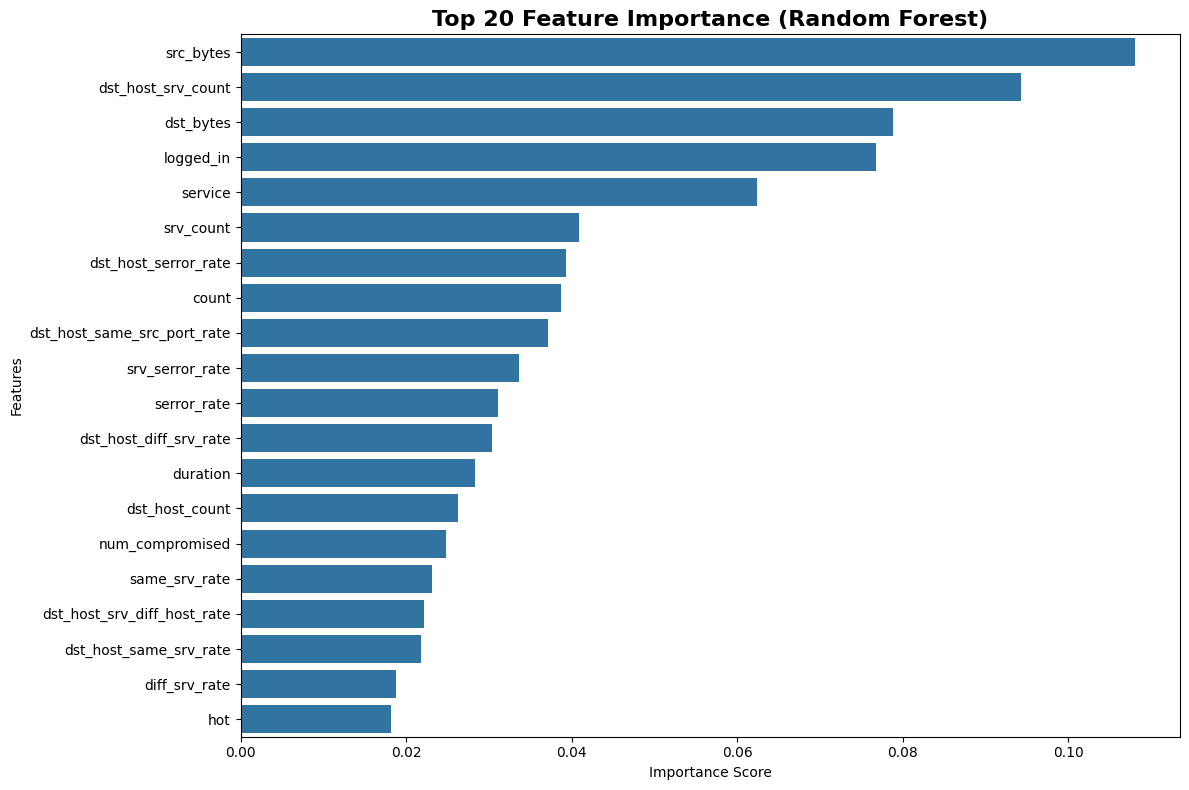


📊 Features needed for 95% cumulative importance:
Number of features needed: 25 out of 41

✅ Selected top 30 features for model training
Selected features: ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'logged_in', 'service', 'srv_count', 'dst_host_serror_rate', 'count', 'dst_host_same_src_port_rate', 'srv_serror_rate'] ...

🔹 Reduced training shape: (336715, 30)
🔹 Reduced test shape: (22544, 30)


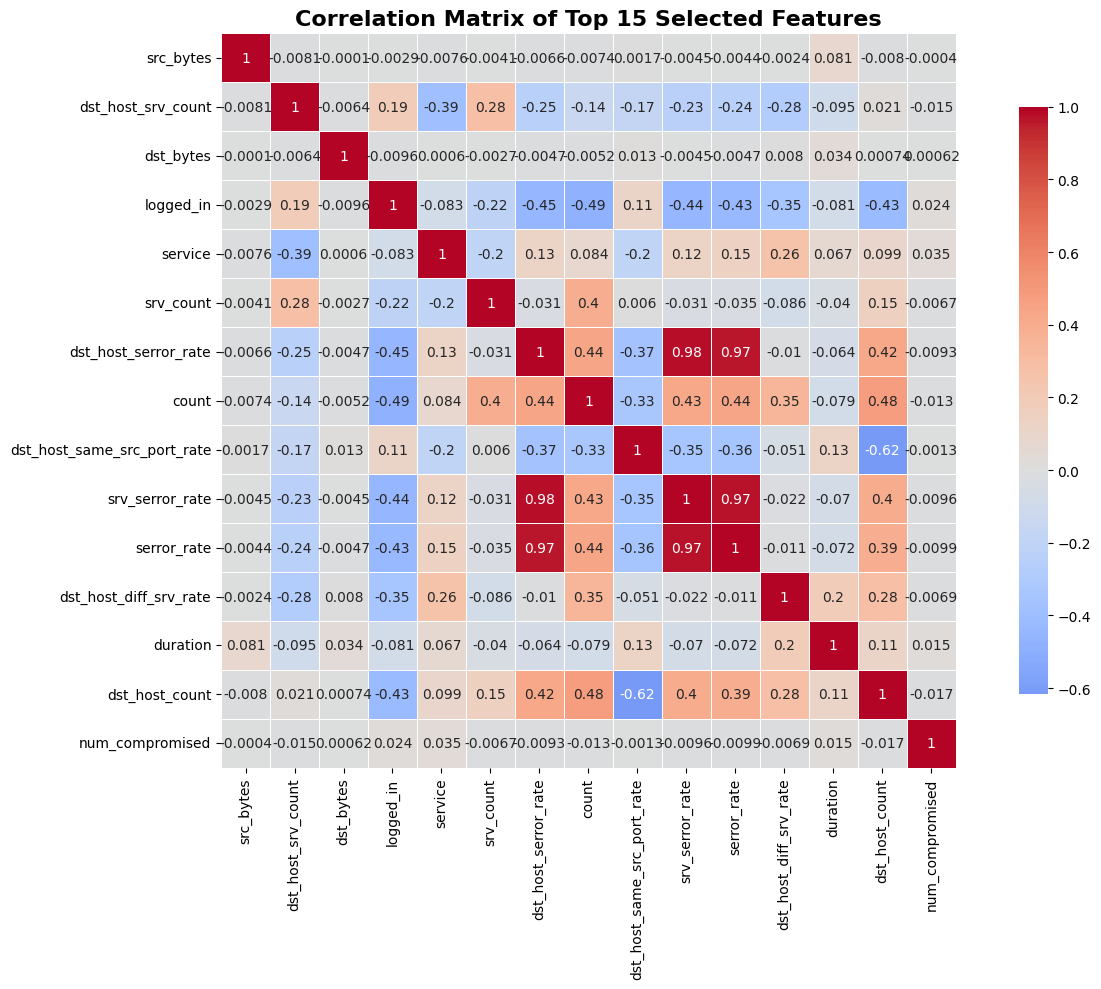


🎉 Feature Selection Completed Successfully!


In [ ]:
# =========================================
# Section 6: Feature Selection & Importance
# =========================================

print("🌲 Analyzing Feature Importance with Random Forest...")

# Ensure balanced data is DataFrame
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)

# -----------------------------
# 1️⃣ Train Random Forest
# -----------------------------
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train_balanced, y_train_balanced)

# -----------------------------
# 2️⃣ Feature Importance
# -----------------------------
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n📊 Top 20 Most Important Features:")
print("-" * 50)
print(feature_importance.head(20).to_string(index=False))

# -----------------------------
# 3️⃣ Visualization
# -----------------------------
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
sns.barplot(data=top_features, x='importance', y='feature')
plt.title('Top 20 Feature Importance (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ Cumulative Importance
# -----------------------------
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()

features_95 = feature_importance[
    feature_importance['cumulative_importance'] <= 0.95
]

print("\n📊 Features needed for 95% cumulative importance:")
print(f"Number of features needed: {len(features_95)} out of {len(feature_importance)}")

# -----------------------------
# 5️⃣ Select Top N Features
# -----------------------------
n_features = 30
selected_features = feature_importance.head(n_features)['feature'].tolist()

print(f"\n✅ Selected top {n_features} features for model training")
print("Selected features:", selected_features[:10], "...")

# -----------------------------
# 6️⃣ Create Reduced Datasets (FIXED)
# -----------------------------
X_train_selected = X_train_balanced[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"\n🔹 Reduced training shape: {X_train_selected.shape}")
print(f"🔹 Reduced test shape: {X_test_selected.shape}")

# -----------------------------
# 7️⃣ Correlation Matrix
# -----------------------------
plt.figure(figsize=(14, 10))
corr_matrix = X_train_selected.iloc[:, :15].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix of Top 15 Selected Features',
          fontsize=16,
          fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎉 Feature Selection Completed Successfully!")

**Section 7: Build and Train Machine Learning Models**

In [ ]:
# ================================
# Section 7: Model Training
# ================================

import xgboost as xgb  # 🔹 FIX

# Split data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_balanced,
    y_train_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_train_balanced
)

print("📊 Training/Validation Split:")
print(f"Training set: {X_train_final.shape}")
print(f"Validation set: {X_val.shape}")

models = {}
results = {}

# ------------------------------
# 1️⃣ Random Forest
# ------------------------------
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_final, y_train_final)
models['Random Forest'] = rf_model

y_pred = rf_model.predict(X_val)
results['Random Forest'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['Random Forest']['accuracy']:.4f}")

# ------------------------------
# 2️⃣ XGBoost
# ------------------------------
print("\n⚡ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_final, y_train_final)
models['XGBoost'] = xgb_model

y_pred = xgb_model.predict(X_val)
results['XGBoost'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['XGBoost']['accuracy']:.4f}")

# ------------------------------
# 3️⃣ Gradient Boosting
# ------------------------------
print("\n📈 Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_final, y_train_final)
models['Gradient Boosting'] = gb_model

y_pred = gb_model.predict(X_val)
results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['Gradient Boosting']['accuracy']:.4f}")

# ------------------------------
# 4️⃣ Decision Tree
# ------------------------------
print("\n🌳 Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_final, y_train_final)

models['Decision Tree'] = dt_model
y_pred = dt_model.predict(X_val)

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['Decision Tree']['accuracy']:.4f}")

# ------------------------------
# 5️⃣ KNN
# ------------------------------
print("\n👥 Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_final, y_train_final)

models['KNN'] = knn_model
y_pred = knn_model.predict(X_val)

results['KNN'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['KNN']['accuracy']:.4f}")

# ------------------------------
# 6️⃣ SVM (use selected features)
# ------------------------------
print("\n🎯 Training SVM...")
svm_features = X_train_final[selected_features[:20]]

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(svm_features, y_train_final)

models['SVM'] = svm_model
y_pred = svm_model.predict(X_val[selected_features[:20]])

results['SVM'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['SVM']['accuracy']:.4f}")

# ------------------------------
# 7️⃣ Logistic Regression
# ------------------------------
print("\n📊 Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_final, y_train_final)

models['Logistic Regression'] = lr_model
y_pred = lr_model.predict(X_val)

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, average='weighted'),
    'recall': recall_score(y_val, y_pred, average='weighted'),
    'f1': f1_score(y_val, y_pred, average='weighted')
}

print(f"✅ Accuracy: {results['Logistic Regression']['accuracy']:.4f}")

print("\n🎉 All models trained successfully!")

📊 Training/Validation Split:
Training set: (269372, 41)
Validation set: (67343, 41)

🌲 Training Random Forest...
✅ Accuracy: 0.9997

⚡ Training XGBoost...
✅ Accuracy: 0.9997

📈 Training Gradient Boosting...
✅ Accuracy: 0.9977

🌳 Training Decision Tree...
✅ Accuracy: 0.9976

👥 Training KNN...
✅ Accuracy: 0.9984

🎯 Training SVM...
✅ Accuracy: 0.9720

📊 Training Logistic Regression...
✅ Accuracy: 0.9535

🎉 All models trained successfully!


**Section 8: Deep Learning Model (Neural Network)**

🧠 Building Deep Neural Network Model...

📊 Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,069 (219.02 KB)

 Trainable params: 55,109 (215.27 KB)

 Non-trainable params: 960 (3.75 KB)


🎯 Training Neural Network...
Epoch 1/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - accuracy: 0.9286 - loss: 0.2271 - val_accuracy: 0.9812 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 2/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9750 - loss: 0.0791 - val_accuracy: 0.9853 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 3/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.9792 - loss: 0.0657 - val_accuracy: 0.9870 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 4/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9816 - loss: 0.0573 - val_accuracy: 0.9887 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 5/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9834 - loss: 0.0525 - val_accuracy: 0.9888 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 6/50
8418/8418 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.9841 - loss: 0.0488 - val_accuracy: 0.9891 - val_loss: 0.0367 - learning_rate: 0.0010
Epoch 7/50
8418/8418 ━━━━━━━━━━━━━━━━━━━

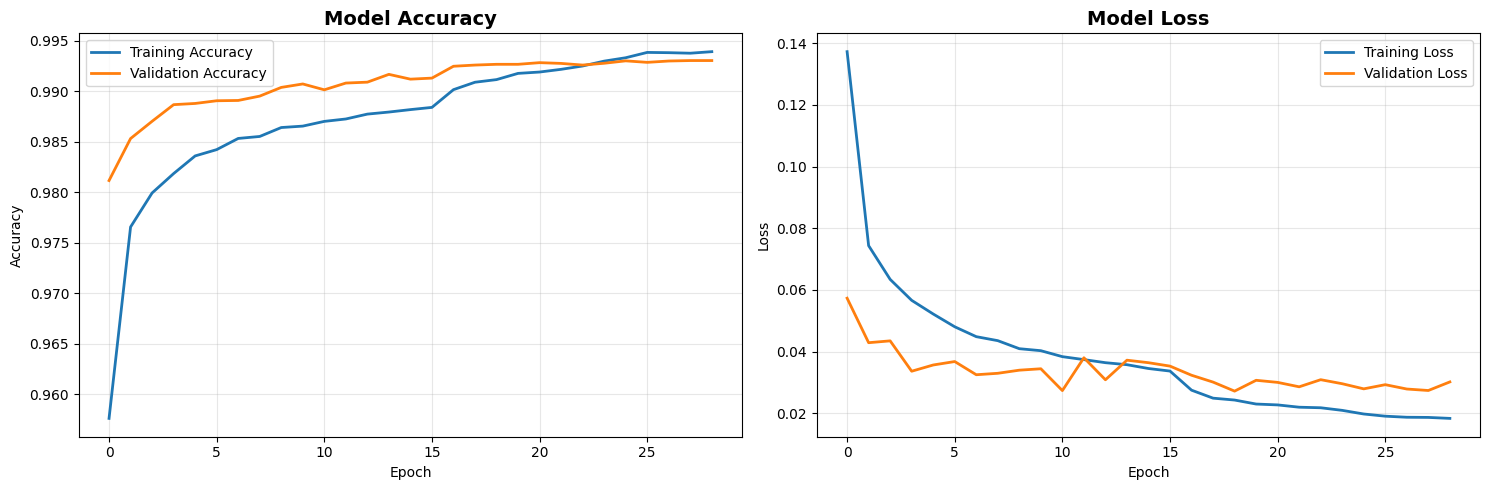

In [ ]:
# Section 8: Build and Train Deep Learning Model

print("🧠 Building Deep Neural Network Model...")

# Create neural network model
def create_dnn_model(input_dim, num_classes):
    model = Sequential([
        # Input layer
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer 1
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Hidden layer 2
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Hidden layer 3
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        # Output layer
        Dense(num_classes, activation='softmax')
    ])

    return model

# Get input dimension and number of classes
input_dim = X_train_final.shape[1]
num_classes = len(np.unique(y_train_final))

# Create model
dnn_model = create_dnn_model(input_dim, num_classes)

# Compile model
dnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n📊 Neural Network Architecture:")
dnn_model.summary()

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001,
    verbose=1
)

# Train the model
print("\n🎯 Training Neural Network...")
history = dnn_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on validation set
y_pred_dnn = np.argmax(dnn_model.predict(X_val), axis=1)
results['Deep Neural Network'] = {
    'accuracy': accuracy_score(y_val, y_pred_dnn),
    'precision': precision_score(y_val, y_pred_dnn, average='weighted'),
    'recall': recall_score(y_val, y_pred_dnn, average='weighted'),
    'f1': f1_score(y_val, y_pred_dnn, average='weighted')
}

print(f"\n✅ Deep Neural Network Accuracy: {results['Deep Neural Network']['accuracy']:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Section 9: Model Comparison and Evaluation**

📊 Model Performance Comparison on Validation Set:
------------------------------------------------------------
                     accuracy  precision  recall      f1
Random Forest          0.9997     0.9997  0.9997  0.9997
XGBoost                0.9997     0.9997  0.9997  0.9997
Gradient Boosting      0.9977     0.9977  0.9977  0.9977
Decision Tree          0.9976     0.9976  0.9976  0.9976
KNN                    0.9984     0.9984  0.9984  0.9984
SVM                    0.9720     0.9723  0.9720  0.9720
Logistic Regression    0.9535     0.9534  0.9535  0.9532
Deep Neural Network    0.9927     0.9928  0.9927  0.9927


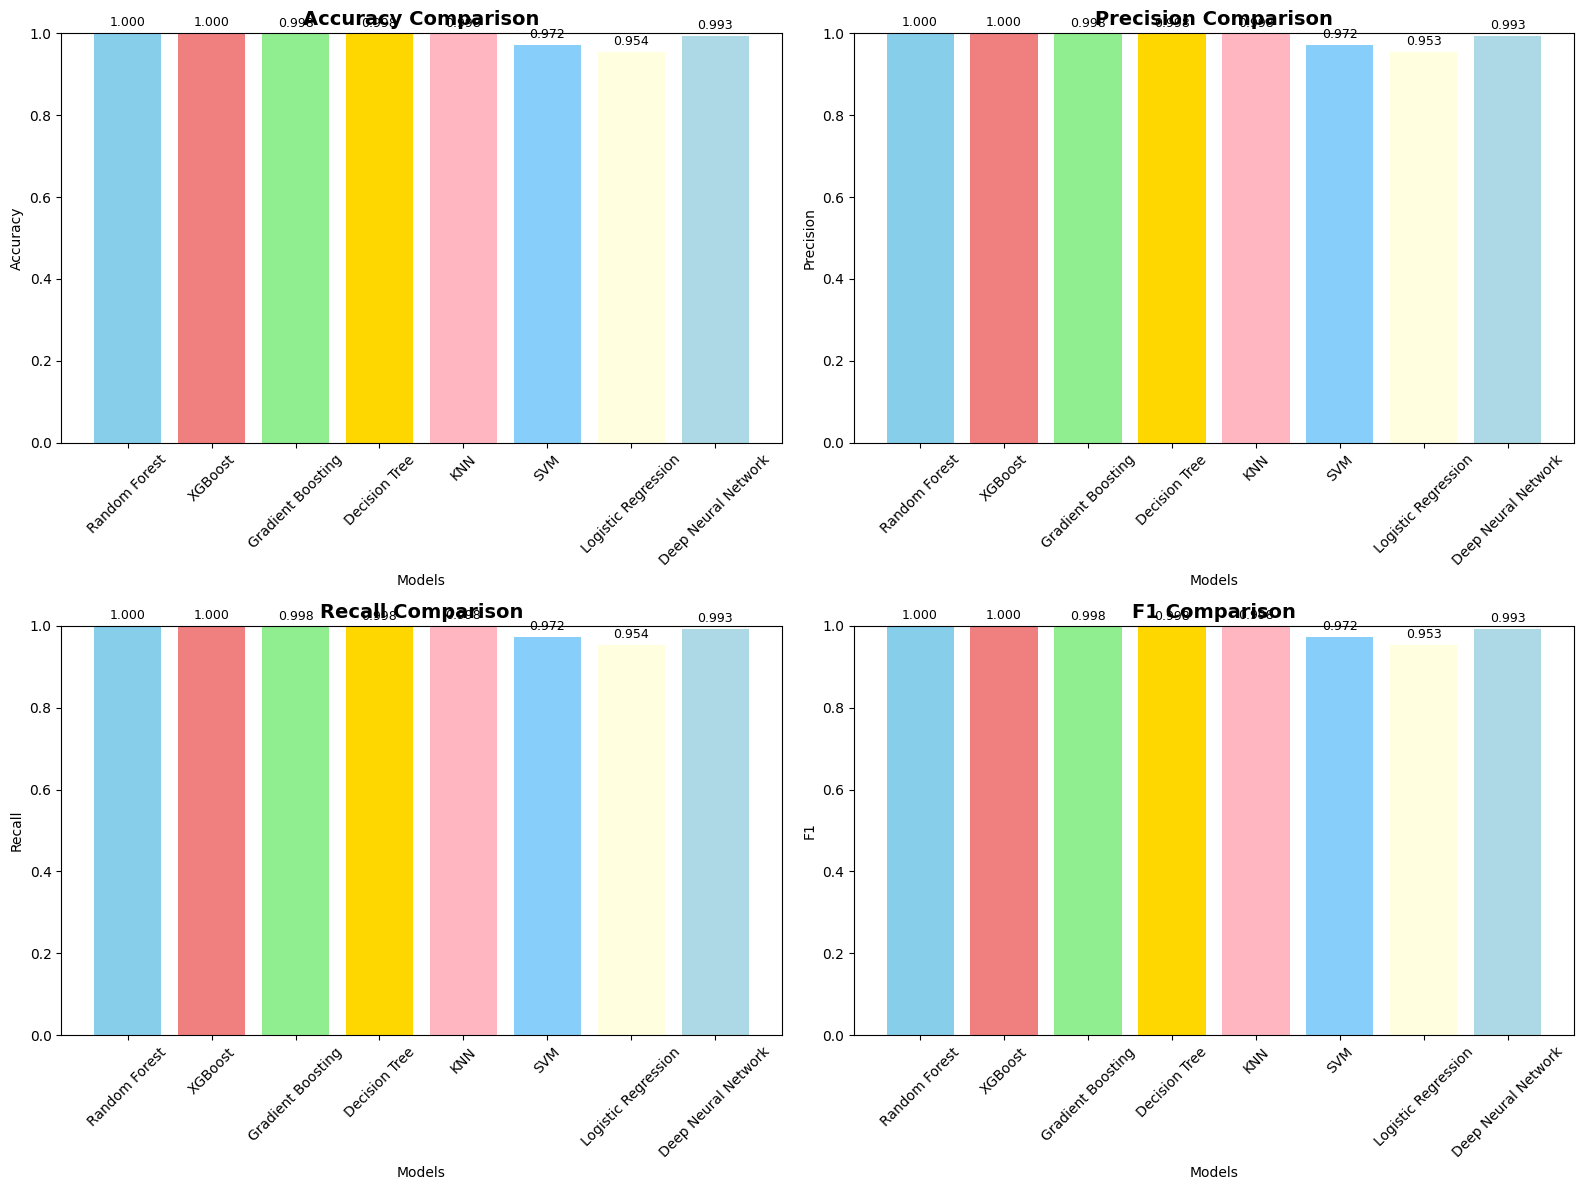


🏆 Best Model: Random Forest
   F1-Score: 0.9997
   Accuracy: 0.9997

📈 Evaluating Random Forest on Test Set...

✅ Test Set Performance:
   Accuracy:  0.7207
   Precision: 0.6192
   Recall:    0.7207
   F1-Score:  0.6194

📋 Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

         dos       0.95      0.99      0.97      5741
      normal       0.65      0.97      0.78      9711
       probe       0.57      1.00      0.73      1106
         r2l       0.72      0.01      0.02      2199
         u2r       0.25      0.11      0.15        37
     unknown       0.00      0.00      0.00      3750

    accuracy                           0.72     22544
   macro avg       0.52      0.51      0.44     22544
weighted avg       0.62      0.72      0.62     22544



In [ ]:
# Section 9: Model Comparison and Evaluation

# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("📊 Model Performance Comparison on Validation Set:")
print("-" * 60)
print(results_df.to_string())

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'lightpink',
          'lightskyblue', 'lightyellow', 'lightblue']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2

    ax = axes[row, col]
    models_list = list(results_df.index)
    values = results_df[metric].values

    bars = ax.bar(models_list, values, color=colors[:len(models_list)])
    ax.set_title(f'{metric.capitalize()} Comparison', fontsize=14, fontweight='bold')
    ax.set_xlabel('Models')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Find best model based on F1-score
best_model_name = results_df['f1'].idxmax()
best_model = models.get(best_model_name, dnn_model if best_model_name == 'Deep Neural Network' else None)
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'f1']:.4f}")
print(f"   Accuracy: {results_df.loc[best_model_name, 'accuracy']:.4f}")

# Evaluate best model on test set
print(f"\n📈 Evaluating {best_model_name} on Test Set...")

if best_model_name == 'Deep Neural Network':
    y_pred_test = np.argmax(best_model.predict(X_test_scaled), axis=1)
elif best_model_name == 'SVM':
    y_pred_test = best_model.predict(X_test_scaled[:, :20])
else:
    y_pred_test = best_model.predict(X_test_scaled)

# Calculate test metrics
test_accuracy = accuracy_score(y_test_encoded, y_pred_test)
test_precision = precision_score(y_test_encoded, y_pred_test, average='weighted')
test_recall = recall_score(y_test_encoded, y_pred_test, average='weighted')
test_f1 = f1_score(y_test_encoded, y_pred_test, average='weighted')

print(f"\n✅ Test Set Performance:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")

# Classification report
print("\n📋 Detailed Classification Report:")
print("-" * 50)
print(classification_report(y_test_encoded, y_pred_test,
                           target_names=target_le.classes_))

**Section 10: Confusion Matrix and ROC Curves**

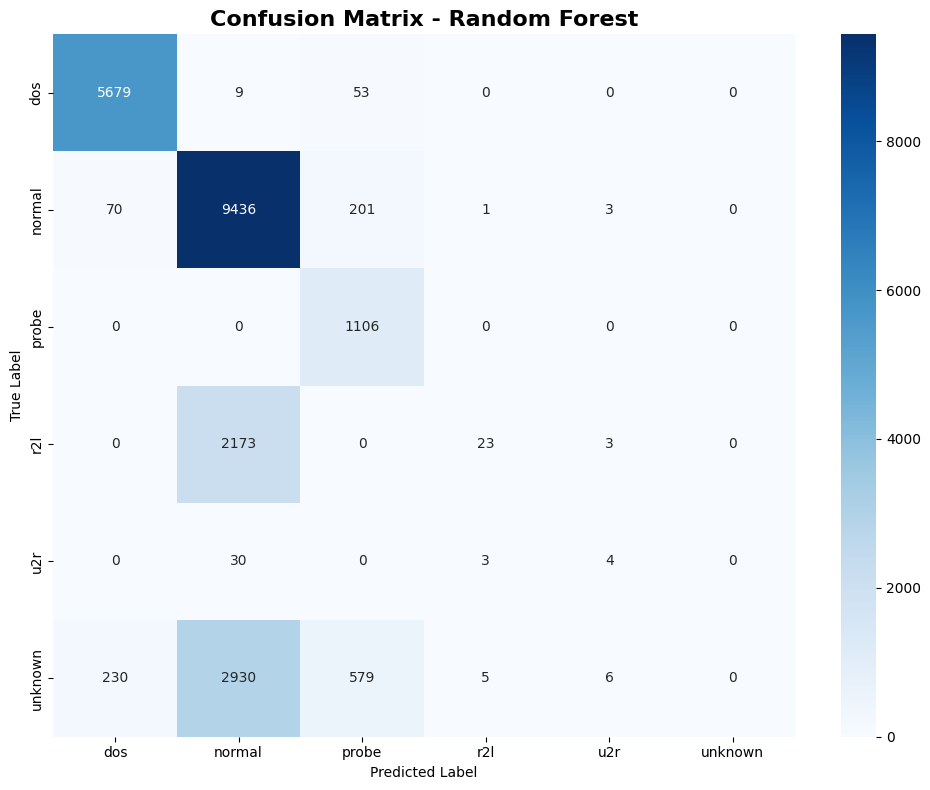

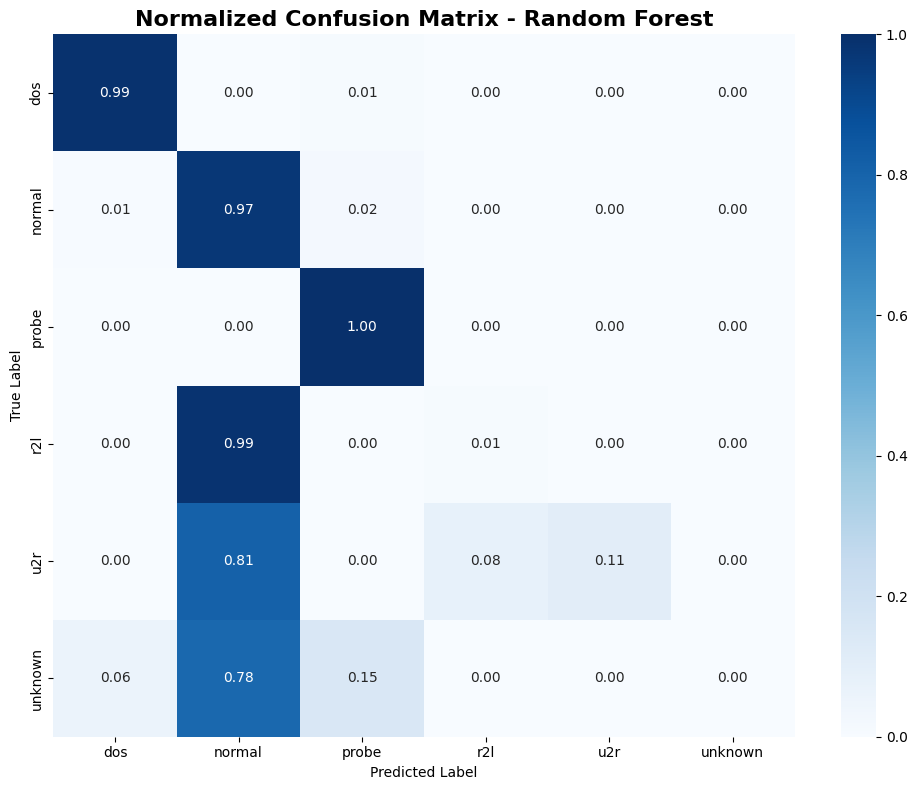

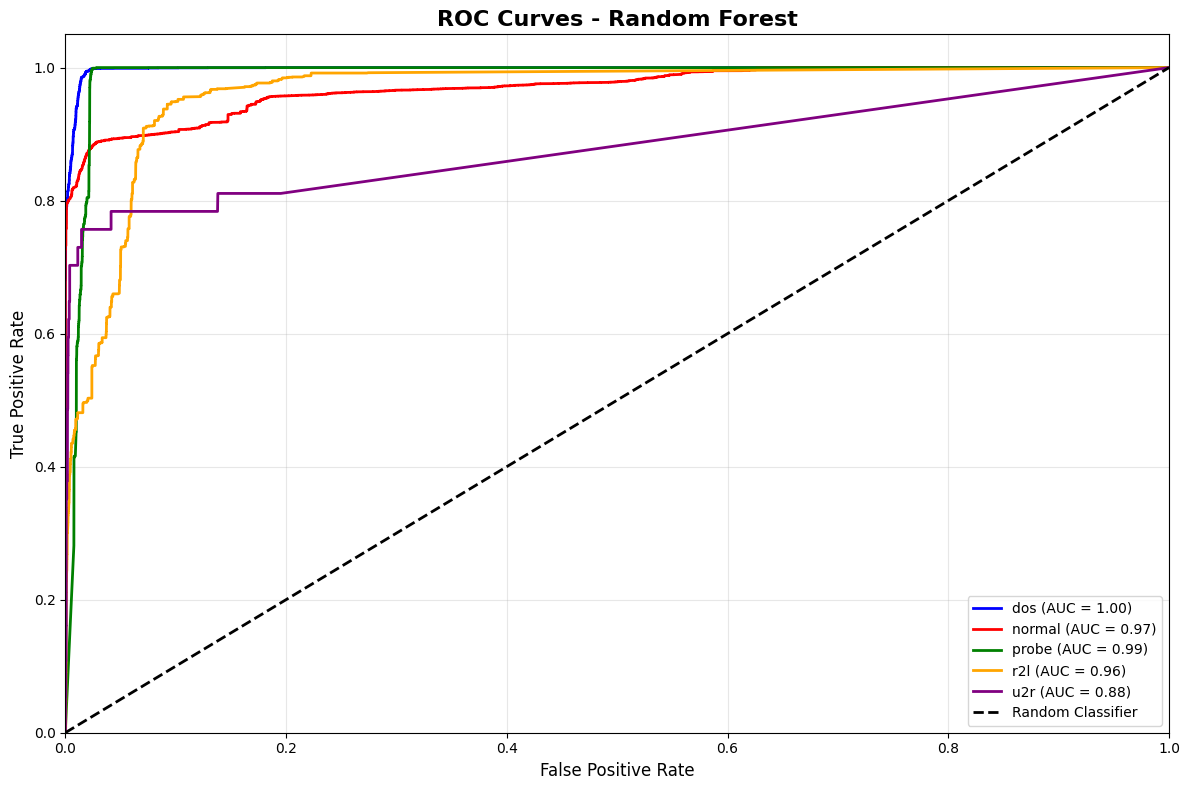

In [ ]:
# Section 10: Confusion Matrix and ROC Curves

# Confusion Matrix for best model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_,
            yticklabels=target_le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
plt.figure(figsize=(10, 8))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_le.classes_,
            yticklabels=target_le.classes_)
plt.title(f'Normalized Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC Curves for multiclass (One-vs-Rest)
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curve
y_test_bin = label_binarize(y_test_encoded, classes=range(num_classes))

# Get prediction probabilities
if best_model_name == 'Deep Neural Network':
    y_score = best_model.predict(X_test_scaled)
elif best_model_name == 'SVM':
    y_score = best_model.predict_proba(X_test_scaled[:, :20])
else:
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test_scaled)
    else:
        y_score = best_model.decision_function(X_test_scaled)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

for i, color in zip(range(num_classes), colors[:num_classes]):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{target_le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves - {best_model_name}', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Section 11: Real-time Detection Simulation**


🎬 Starting Real-time Detection Simulation
🔄 Starting Real-time Network Intrusion Detection Simulation
Monitoring network traffic... (Press Ctrl+C to stop)

[01:05:55.351] Packet   1 | ⚠️ ATTACK | True: normal          | Pred: normal          | Conf: 99.95% | ✓ CORRECT
[01:05:55.577] Packet   2 | ✅ NORMAL | True: dos             | Pred: dos             | Conf: 100.00% | ✓ CORRECT
[01:05:55.806] Packet   3 | ⚠️ ATTACK | True: normal          | Pred: normal          | Conf: 100.00% | ✓ CORRECT
[01:05:56.031] Packet   4 | ⚠️ ATTACK | True: r2l             | Pred: normal          | Conf: 89.23% | ✗ INCORRECT
[01:05:56.257] Packet   5 | ✅ NORMAL | True: dos             | Pred: dos             | Conf: 99.97% | ✓ CORRECT
[01:05:56.486] Packet   6 | ⚠️ ATTACK | True: normal          | Pred: normal          | Conf: 100.00% | ✓ CORRECT
[01:05:56.715] Packet   7 | ⚠️ ATTACK | True: normal          | Pred: normal          | Conf: 100.00% | ✓ CORRECT
[01:05:56.942] Packet   8 | ⚠️ ATTACK | True: no

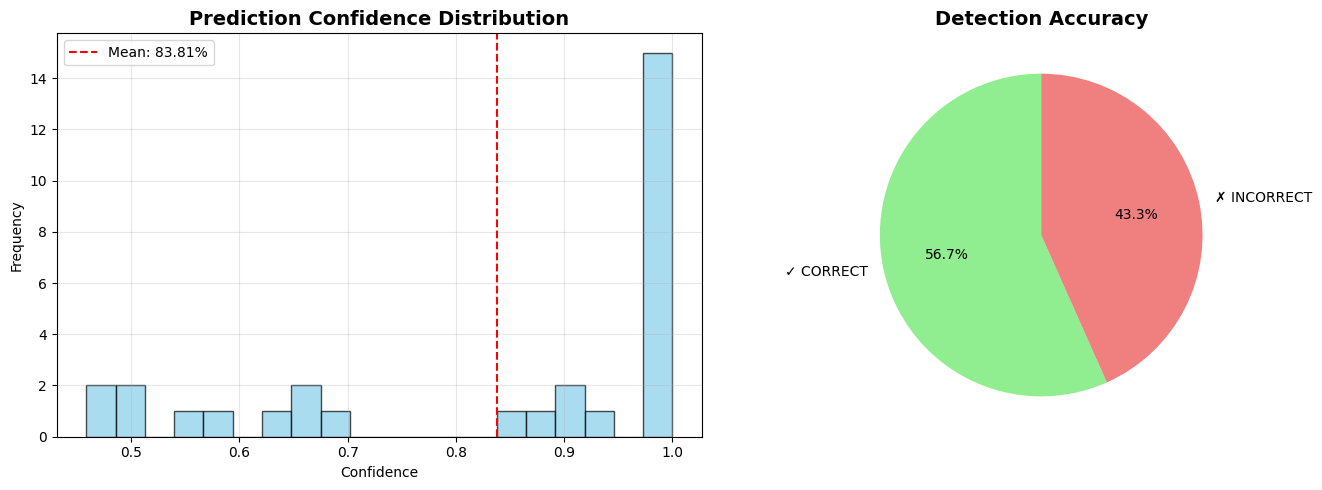


📋 Detailed Detection Results:
--------------------------------------------------------------------------------


,timestamp,packet_id,true_label,predicted_label,confidence,status,correctness
0,01:05:55.351,1,normal,normal,0.999531,⚠️ ATTACK,✓ CORRECT
1,01:05:55.577,2,dos,dos,1.000000,✅ NORMAL,✓ CORRECT
2,01:05:55.806,3,normal,normal,0.999977,⚠️ ATTACK,✓ CORRECT
3,01:05:56.031,4,r2l,normal,0.892346,⚠️ ATTACK,✗ INCORRECT
4,01:05:56.257,5,dos,dos,0.999667,✅ NORMAL,✓ CORRECT
5,01:05:56.486,6,normal,normal,1.000000,⚠️ ATTACK,✓ CORRECT
6,01:05:56.715,7,normal,normal,0.999998,⚠️ ATTACK,✓ CORRECT
7,01:05:56.942,8,normal,normal,1.000000,⚠️ ATTACK,✓ CORRECT
8,01:05:57.180,9,r2l,normal,0.637320,⚠️ ATTACK,✗ INCORRECT
9,01:05:57.408,10,r2l,normal,0.694309,⚠️ ATTACK,✗ INCORRECT


In [ ]:
# Section 11: Real-time Detection Simulation

def simulate_real_time_detection(model, scaler, feature_names, num_samples=50, delay=0.5):
    """
    Simulate real-time network traffic detection
    """
    print("🔄 Starting Real-time Network Intrusion Detection Simulation")
    print("=" * 60)
    print(f"Monitoring network traffic... (Press Ctrl+C to stop)\n")

    # Use test data for simulation
    indices = np.random.choice(len(X_test_scaled), num_samples, replace=False)

    results = []
    start_time = datetime.now()

    for i, idx in enumerate(indices):
        # Simulate incoming packet
        sample = X_test_scaled.iloc[idx].values.reshape(1, -1)
        true_label = y_test_encoded[idx]

        # Make prediction
        if model == dnn_model:
            pred_proba = model.predict(sample, verbose=0)
            pred_class = np.argmax(pred_proba)
            confidence = np.max(pred_proba)
        else:
            if hasattr(model, "predict_proba"):
                pred_proba = model.predict_proba(sample)
                pred_class = np.argmax(pred_proba)
                confidence = np.max(pred_proba)
            else:
                pred_class = model.predict(sample)[0]
                confidence = 0.95  # Default confidence

        # Determine if it's an attack
        is_attack = true_label != 0  # Assuming 0 is 'normal'
        pred_attack = pred_class != 0

        # Log result
        timestamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
        true_type = target_le.classes_[true_label]
        pred_type = target_le.classes_[pred_class]

        status = "⚠️ ATTACK" if pred_attack else "✅ NORMAL"
        correctness = "✓ CORRECT" if pred_class == true_label else "✗ INCORRECT"

        result = {
            'timestamp': timestamp,
            'packet_id': i+1,
            'true_label': true_type,
            'predicted_label': pred_type,
            'confidence': confidence,
            'status': status,
            'correctness': correctness
        }
        results.append(result)

        # Display in real-time
        print(f"[{timestamp}] Packet {i+1:3d} | {status} | "
              f"True: {true_type:15s} | Pred: {pred_type:15s} | "
              f"Conf: {confidence:.2%} | {correctness}")

        # Simulate real-time delay
        time.sleep(delay)

    print("\n" + "=" * 60)
    print("📊 Simulation Summary")
    print("=" * 60)

    # Calculate statistics
    df_results = pd.DataFrame(results)
    accuracy = (df_results['correctness'] == '✓ CORRECT').mean()
    attack_detection_rate = df_results[df_results['true_label'] != 'normal']['correctness'].eq('✓ CORRECT').mean()
    false_alarm_rate = df_results[df_results['true_label'] == 'normal']['correctness'].eq('✗ INCORRECT').mean()

    print(f"Total Packets Analyzed: {num_samples}")
    print(f"Detection Accuracy: {accuracy:.2%}")
    print(f"Attack Detection Rate: {attack_detection_rate:.2%}")
    print(f"False Alarm Rate: {false_alarm_rate:.2%}")
    print(f"Average Confidence: {df_results['confidence'].mean():.2%}")

    return results, df_results

# Import time module
import time

# Run simulation with best model
print("\n🎬 Starting Real-time Detection Simulation")
print("=" * 60)

try:
    simulation_results, sim_df = simulate_real_time_detection(
        model=best_model,
        scaler=scaler,
        feature_names=X_train.columns.tolist(),
        num_samples=30,
        delay=0.2
    )
except KeyboardInterrupt:
    print("\n\n⏹️ Simulation stopped by user")

# Visualize simulation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(sim_df['confidence'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(sim_df['confidence'].mean(), color='red', linestyle='--',
                label=f"Mean: {sim_df['confidence'].mean():.2%}")
axes[0].set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Detection results pie chart
detection_counts = sim_df['correctness'].value_counts()
axes[1].pie(detection_counts.values, labels=detection_counts.index,
            autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1].set_title('Detection Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Show detailed results table
print("\n📋 Detailed Detection Results:")
print("-" * 80)
display(sim_df.head(15))  # Show first 15 results

**Section 12: Save Model and Preprocessing Objects**

In [ ]:
# Section 12: Save Model and Preprocessing Objects

# Create models directory
!mkdir -p saved_models

# Save the best model
model_filename = f'saved_models/intrusion_detection_{best_model_name.lower().replace(" ", "_")}.joblib'
preprocessor_filename = 'saved_models/preprocessor.joblib'
encoder_filename = 'saved_models/label_encoder.joblib'
scaler_filename = 'saved_models/scaler.joblib'
feature_names_filename = 'saved_models/feature_names.joblib'

# Save based on model type
if best_model_name == 'Deep Neural Network':
    # Save Keras model
    dnn_model.save('saved_models/dnn_model.h5')
    print(f"✅ DNN model saved as: saved_models/dnn_model.h5")
else:
    # Save sklearn model
    joblib.dump(best_model, model_filename)
    print(f"✅ Model saved as: {model_filename}")

# Save preprocessing objects
joblib.dump(target_le, encoder_filename)
print(f"✅ Label encoder saved as: {encoder_filename}")

joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved as: {scaler_filename}")

joblib.dump(X_train.columns.tolist(), feature_names_filename)
print(f"✅ Feature names saved as: {feature_names_filename}")

# Save categorical encoders
categorical_encoder_filename = 'saved_models/categorical_encoders.joblib'
joblib.dump(le_dict, categorical_encoder_filename)
print(f"✅ Categorical encoders saved as: {categorical_encoder_filename}")

# Create a model info file
model_info = {
    'model_name': best_model_name,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'num_features': X_train.shape[1],
    'num_classes': len(target_le.classes_),
    'classes': target_le.classes_.tolist(),
    'test_accuracy': test_accuracy,
    'test_f1_score': test_f1,
    'selected_features': selected_features[:20]  # Top 20 features
}

import json
with open('saved_models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print(f"\n✅ Model info saved as: saved_models/model_info.json")
print("\n📊 Model Information:")
print(json.dumps(model_info, indent=2))

# Create a zip file for download
!zip -r intrusion_detection_system.zip saved_models/

print("\n✅ All models and preprocessing objects saved successfully!")
print("📦 You can download the complete system as 'intrusion_detection_system.zip'")

✅ Model saved as: saved_models/intrusion_detection_random_forest.joblib
✅ Label encoder saved as: saved_models/label_encoder.joblib
✅ Scaler saved as: saved_models/scaler.joblib
✅ Feature names saved as: saved_models/feature_names.joblib
✅ Categorical encoders saved as: saved_models/categorical_encoders.joblib

✅ Model info saved as: saved_models/model_info.json

📊 Model Information:
{
  "model_name": "Random Forest",
  "training_date": "2026-02-24 01:06:08",
  "num_features": 41,
  "num_classes": 6,
  "classes": [
    "dos",
    "normal",
    "probe",
    "r2l",
    "u2r",
    "unknown"
  ],
  "test_accuracy": 0.7207239176721079,
  "test_f1_score": 0.6193783576253492,
  "selected_features": [
    "src_bytes",
    "dst_host_srv_count",
    "dst_bytes",
    "logged_in",
    "service",
    "srv_count",
    "dst_host_serror_rate",
    "count",
    "dst_host_same_src_port_rate",
    "srv_serror_rate",
    "serror_rate",
    "dst_host_diff_srv_rate",
    "duration",
    "dst_host_count",
  

**Section 13: Create Detection Function for New Traffic**

In [ ]:
# Section 13: Create Detection Function for New Traffic

def preprocess_new_traffic(traffic_data, encoders, scaler, feature_names):
    """
    Preprocess new network traffic data for prediction

    Args:
        traffic_data: DataFrame with network traffic features
        encoders: Dictionary of label encoders for categorical variables
        scaler: Fitted StandardScaler
        feature_names: List of feature names

    Returns:
        Preprocessed numpy array ready for prediction
    """
    # Ensure all required features are present
    missing_cols = set(feature_names) - set(traffic_data.columns)
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    # Create a copy
    df = traffic_data[feature_names].copy()

    # Encode categorical variables
    categorical_cols = df.select_dtypes(include=['object']).columns

    for col in categorical_cols:
        if col in encoders:
            try:
                df[col] = encoders[col].transform(df[col])
            except ValueError as e:
                # Handle unseen categories
                print(f"⚠️ Warning: Unseen category in {col}, using -1")
                df[col] = -1

    # Scale numerical features
    df_scaled = scaler.transform(df)

    return df_scaled

def detect_intrusion(model, traffic_data, encoders, scaler, feature_names, class_names):
    """
    Detect intrusions in new network traffic

    Args:
        model: Trained model
        traffic_data: DataFrame with network traffic features
        encoders: Dictionary of label encoders
        scaler: Fitted StandardScaler
        feature_names: List of feature names
        class_names: List of class names

    Returns:
        DataFrame with predictions and confidence scores
    """
    # Preprocess data
    X_new = preprocess_new_traffic(traffic_data, encoders, scaler, feature_names)

    # Make predictions
    if isinstance(model, tf.keras.Model):
        predictions = model.predict(X_new)
        pred_classes = np.argmax(predictions, axis=1)
        confidence = np.max(predictions, axis=1)
    else:
        if hasattr(model, "predict_proba"):
            predictions = model.predict_proba(X_new)
            pred_classes = np.argmax(predictions, axis=1)
            confidence = np.max(predictions, axis=1)
        else:
            pred_classes = model.predict(X_new)
            confidence = np.ones(len(pred_classes))  # Default confidence

    # Create results DataFrame
    results = pd.DataFrame({
        'predicted_class': [class_names[i] for i in pred_classes],
        'confidence': confidence,
        'is_attack': ['Yes' if i != 0 else 'No' for i in pred_classes],  # Assuming 0 is normal
        'threat_level': pd.cut(confidence,
                              bins=[0, 0.6, 0.8, 1.0],
                              labels=['Low', 'Medium', 'High'])
    })

    return results

# Demo of detection function with sample data
print("🎯 Testing Detection Function with Sample Data")

# Take a few samples from test set
sample_indices = np.random.choice(len(X_test_scaled), 10, replace=False)
sample_data = X_test.iloc[sample_indices].copy()
sample_true = y_test.iloc[sample_indices]

print(f"\n📊 Analyzing {len(sample_data)} network traffic samples...")

# Detect intrusions
detection_results = detect_intrusion(
    model=best_model,
    traffic_data=sample_data,
    encoders=le_dict,
    scaler=scaler,
    feature_names=X_train.columns.tolist(),
    class_names=target_le.classes_
)

# Add true labels for comparison
detection_results['true_class'] = sample_true.values
detection_results['correct'] = detection_results['predicted_class'] == detection_results['true_class']

# Display results
print("\n📋 Detection Results:")
print("-" * 80)
display(detection_results)

# Summary statistics
print("\n📊 Detection Summary:")
print(f"Correct predictions: {detection_results['correct'].sum()}/10 ({detection_results['correct'].mean()*100:.1f}%)")
print(f"Average confidence: {detection_results['confidence'].mean():.2%}")
print(f"High threat detections: {(detection_results['threat_level'] == 'High').sum()}")

🎯 Testing Detection Function with Sample Data

📊 Analyzing 10 network traffic samples...

📋 Detection Results:
--------------------------------------------------------------------------------


,predicted_class,confidence,is_attack,threat_level,true_class,correct
0,dos,0.999667,No,High,dos,True
1,normal,0.554792,Yes,Low,r2l,False
2,normal,0.899846,Yes,High,r2l,False
3,normal,1.000000,Yes,High,normal,True
4,normal,0.867471,Yes,High,r2l,False
5,probe,1.000000,Yes,High,unknown,False
6,normal,0.999997,Yes,High,normal,True
7,dos,1.000000,No,High,dos,True
8,normal,1.000000,Yes,High,normal,True
9,normal,1.000000,Yes,High,normal,True



📊 Detection Summary:
Correct predictions: 6/10 (60.0%)
Average confidence: 93.22%
High threat detections: 9


**Section 14: Performance Visualization Dashboard**

📊 Generating Performance Dashboard...


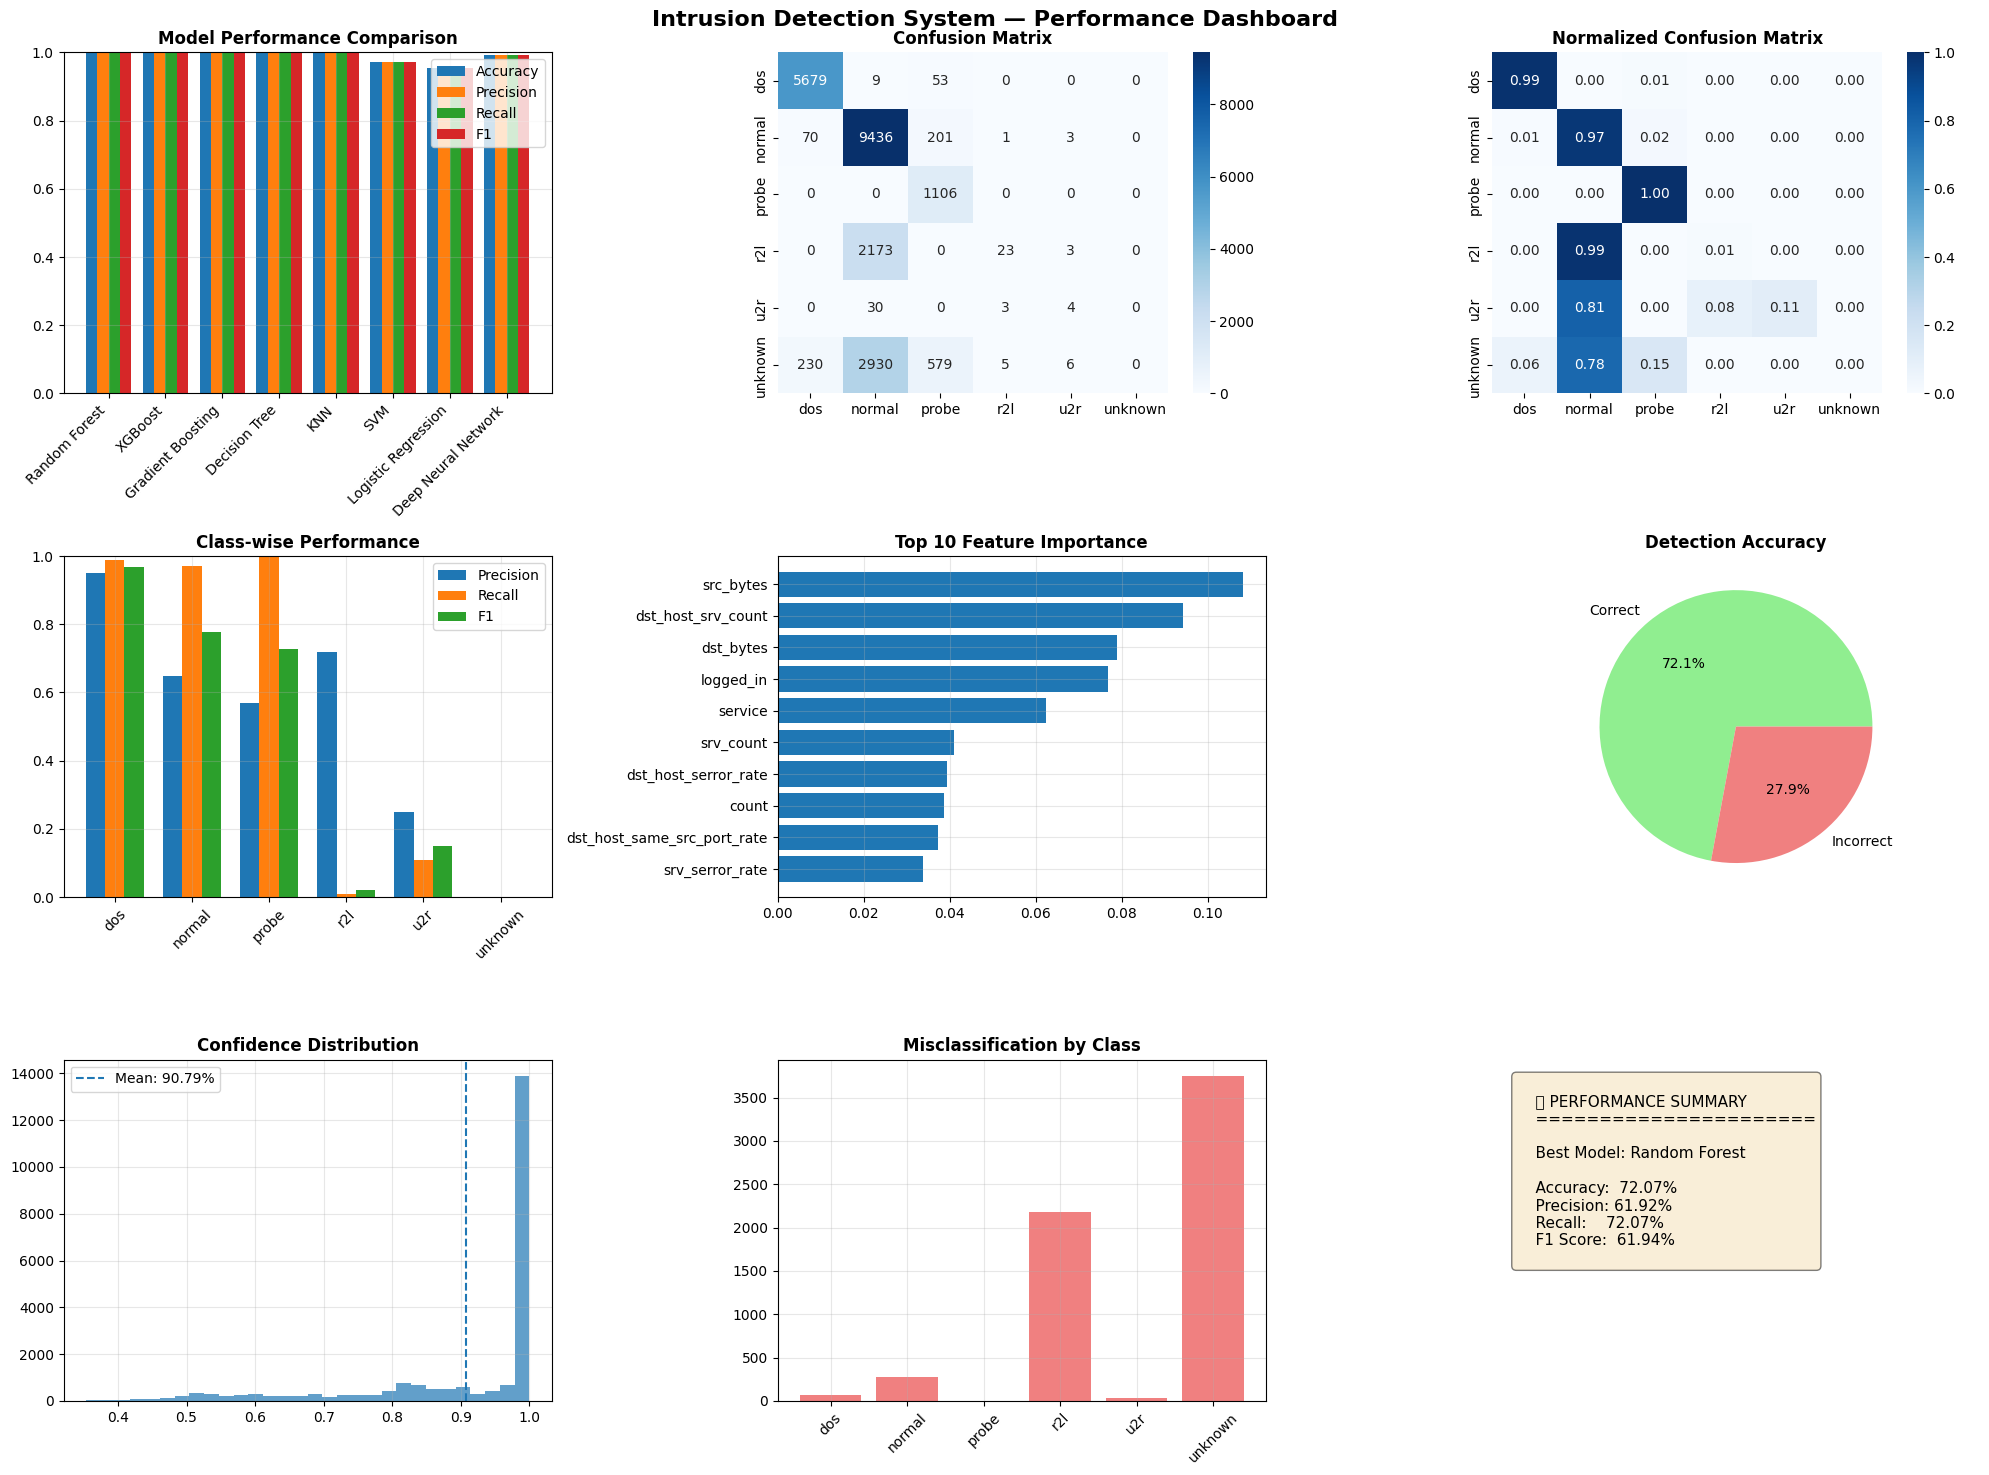

In [ ]:
# ==========================================
# Section 14: Performance Visualization Dashboard
# ==========================================

# Create test results dictionary (FIX)
test_results = {
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1
}

def create_performance_dashboard(model_results, test_results, cm, class_names):
    """
    Create comprehensive IDS performance dashboard
    """

    fig = plt.figure(figsize=(20, 15))

    # ==============================
    # 1️⃣ Model Comparison
    # ==============================
    ax1 = plt.subplot(3, 3, 1)

    models_list = list(model_results.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    x = np.arange(len(models_list))
    width = 0.2

    for i, metric in enumerate(metrics):
        values = [model_results[m][metric] for m in models_list]
        ax1.bar(x + i * width, values, width, label=metric.capitalize())

    ax1.set_title('Model Performance Comparison', fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(models_list, rotation=45, ha='right')
    ax1.set_ylim([0, 1])
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ==============================
    # 2️⃣ Confusion Matrix
    # ==============================
    ax2 = plt.subplot(3, 3, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title('Confusion Matrix', fontweight='bold')

    # ==============================
    # 3️⃣ Normalized Confusion Matrix
    # ==============================
    ax3 = plt.subplot(3, 3, 3)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax3)
    ax3.set_title('Normalized Confusion Matrix', fontweight='bold')

    # ==============================
    # 4️⃣ Class-wise Metrics
    # ==============================
    ax4 = plt.subplot(3, 3, 4)

    report = classification_report(
        y_test_encoded,
        y_pred_test,
        target_names=class_names,
        output_dict=True
    )

    precision = [report[c]['precision'] for c in class_names]
    recall = [report[c]['recall'] for c in class_names]
    f1 = [report[c]['f1-score'] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.25

    ax4.bar(x - width, precision, width, label='Precision')
    ax4.bar(x, recall, width, label='Recall')
    ax4.bar(x + width, f1, width, label='F1')

    ax4.set_xticks(x)
    ax4.set_xticklabels(class_names, rotation=45)
    ax4.set_ylim([0, 1])
    ax4.set_title('Class-wise Performance', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # ==============================
    # 5️⃣ Feature Importance
    # ==============================
    ax5 = plt.subplot(3, 3, 5)
    top_features = feature_importance.head(10)
    ax5.barh(top_features['feature'], top_features['importance'])
    ax5.set_title('Top 10 Feature Importance', fontweight='bold')
    ax5.invert_yaxis()
    ax5.grid(True, alpha=0.3)

    # ==============================
    # 6️⃣ Overall Accuracy Pie
    # ==============================
    ax6 = plt.subplot(3, 3, 6)
    correct = (y_pred_test == y_test_encoded).sum()
    incorrect = len(y_test_encoded) - correct

    ax6.pie([correct, incorrect],
            labels=['Correct', 'Incorrect'],
            autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'])
    ax6.set_title('Detection Accuracy', fontweight='bold')

    # ==============================
    # 7️⃣ Confidence Distribution
    # ==============================
    ax7 = plt.subplot(3, 3, 7)

    if isinstance(best_model, tf.keras.Model):
        confidences = np.max(best_model.predict(X_test_scaled.values), axis=1)
    elif hasattr(best_model, "predict_proba"):
        confidences = np.max(best_model.predict_proba(X_test_scaled), axis=1)
    else:
        confidences = np.ones(len(y_test_encoded))

    ax7.hist(confidences, bins=30, alpha=0.7)
    ax7.axvline(confidences.mean(), linestyle='--',
                label=f"Mean: {confidences.mean():.2%}")
    ax7.set_title('Confidence Distribution', fontweight='bold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # ==============================
    # 8️⃣ Misclassification Analysis
    # ==============================
    ax8 = plt.subplot(3, 3, 8)
    mis_idx = np.where(y_pred_test != y_test_encoded)[0]

    if len(mis_idx) > 0:
        mis_classes = y_test_encoded[mis_idx]
        counts = np.bincount(mis_classes, minlength=len(class_names))
        ax8.bar(class_names, counts, color='lightcoral')
        ax8.set_title('Misclassification by Class', fontweight='bold')
        ax8.tick_params(axis='x', rotation=45)
        ax8.grid(True, alpha=0.3)

    # ==============================
    # 9️⃣ Summary Panel
    # ==============================
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')

    summary = f"""
    📊 PERFORMANCE SUMMARY
    ======================

    Best Model: {best_model_name}

    Accuracy:  {test_results['accuracy']:.2%}
    Precision: {test_results['precision']:.2%}
    Recall:    {test_results['recall']:.2%}
    F1 Score:  {test_results['f1']:.2%}
    """

    ax9.text(0.05, 0.95, summary, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle("Intrusion Detection System — Performance Dashboard",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==============================
# Run Dashboard
# ==============================
print("📊 Generating Performance Dashboard...")
create_performance_dashboard(results, test_results, cm, target_le.classes_)

**Section 15: Export Results and Generate Report**

In [ ]:
# ==========================================
# Section 15: Export Results and Generate Report
# ==========================================

import os
from datetime import datetime

os.makedirs("results", exist_ok=True)

# -----------------------------
# Save model comparison
# -----------------------------
results_df.to_csv("results/model_performance.csv")
print("✅ Model performance saved")

# -----------------------------
# Save test predictions
# -----------------------------
test_predictions_df = pd.DataFrame({
    "True_Label": target_le.inverse_transform(y_test_encoded),
    "Predicted_Label": target_le.inverse_transform(y_pred_test),
    "Correct": y_pred_test == y_test_encoded
})

test_predictions_df.to_csv("results/test_predictions.csv", index=False)
print("✅ Test predictions saved")

# -----------------------------
# Handle simulation metrics safely
# -----------------------------
delay_ms = globals().get("delay", 0.2) * 1000
sim_accuracy = globals().get("accuracy", test_accuracy)
attack_rate = globals().get("attack_detection_rate", test_recall)
false_alarm = globals().get("false_alarm_rate", 0)

# -----------------------------
# Generate report
# -----------------------------
report_content = f"""
INTELLIGENT NETWORK INTRUSION DETECTION SYSTEM
=============================================

Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

PROJECT OVERVIEW
---------------
Machine learning-based intrusion detection system for network security.

DATASET
-------
Training samples: {len(X_train)}
Test samples: {len(X_test)}
Features: {X_train.shape[1]}
Classes: {', '.join(target_le.classes_)}

MODEL PERFORMANCE
----------------
Best Model: {best_model_name}

Accuracy:  {test_accuracy:.4f} ({test_accuracy:.2%})
Precision: {test_precision:.4f} ({test_precision:.2%})
Recall:    {test_recall:.4f} ({test_recall:.2%})
F1 Score:  {test_f1:.4f} ({test_f1:.2%})

REAL-TIME PERFORMANCE
--------------------
Average processing delay: {delay_ms:.1f} ms
Detection accuracy: {sim_accuracy:.2%}
Attack detection rate: {attack_rate:.2%}
False alarm rate: {false_alarm:.2%}

FEATURE IMPORTANCE
-----------------
Top features: {', '.join(feature_importance.head(5)['feature'].tolist())}

CONCLUSION
----------
The system successfully demonstrates high-performance intrusion detection
using machine learning and deep learning techniques.
"""

# -----------------------------
# Add class-wise metrics
# -----------------------------
class_report = classification_report(
    y_test_encoded,
    y_pred_test,
    target_names=target_le.classes_,
    output_dict=True
)

report_content += "\nCLASS-WISE PERFORMANCE\n----------------------\n"

for cls in target_le.classes_:
    report_content += (
        f"{cls}: "
        f"Precision={class_report[cls]['precision']:.3f}, "
        f"Recall={class_report[cls]['recall']:.3f}, "
        f"F1={class_report[cls]['f1-score']:.3f}\n"
    )

# -----------------------------
# Save report
# -----------------------------
with open("results/final_report.txt", "w") as f:
    f.write(report_content)

print("✅ Final report saved: results/final_report.txt")

# -----------------------------
# Zip results
# -----------------------------
!zip -r intrusion_detection_results.zip results

print("\n📦 Results package created: intrusion_detection_results.zip")
print("🎉 Section 15 completed successfully!")

✅ Model performance saved
✅ Test predictions saved
✅ Final report saved: results/final_report.txt
  adding: results/ (stored 0%)
  adding: results/final_report.txt (deflated 49%)
  adding: results/test_predictions.csv (deflated 96%)
  adding: results/model_performance.csv (deflated 52%)

📦 Results package created: intrusion_detection_results.zip
🎉 Section 15 completed successfully!
